# Hello World: Training `neural-lam` on DANRA

This notebook provides a **beginner-friendly, end-to-end walkthrough** for running a minimal model training pipeline in `neural-lam` using a small, public DANRA dataset.

It covers:
1. Environment setup (CPU-safe)
2. Data preprocessing with `mllam-data-prep`
3. Graph generation (single-level, for speed)
4. Training for 1 epoch on CPU
5. Evaluation and example predictions
6. Scaling tips for bigger runs

---

### Prerequisites and Context

> **Important:** This notebook is designed to be run from inside a **local clone** of [`mllam/neural-lam`](https://github.com/mllam/neural-lam). All paths are relative to the repository root.
> 
> **Paper Reference:** For an in-depth context on the models used here, please refer to the paper \
    "Building Machine Learning Limited Area Models: Kilometer-Scale Weather Forecasting in Realistic Settings" \
    (Adamov et al., 2025) available at [arXiv:2504.09340](https://arxiv.org/abs/2504.09340).
>
> **Python Version:** Make sure you are using a Python version supported by the project (e.g. 3.10–3.12) with `ipykernel` installed.
> 
> **Note on Future Graph Updates:** The graph generation step currently uses `create_graph.py`, but it will be migrated to use the upcoming `weather-model-graphs` package in the near future.


In [1]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import Image, display

import neural_lam
from neural_lam.config import load_config_and_datastore
from neural_lam import utils
from neural_lam.plot_graph import plot_graph as _plot_graph


/home/sharkyi/myenv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/home/sharkyi/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Verify we are at the repo root (should see neural_lam/, docs/, tests/, etc.)
print("Current directory:", os.getcwd())
print("Repo contents:", [f for f in os.listdir(".") if not f.startswith(".")])

Current directory: /home/sharkyi/Desktop/1/neural-lam/docs/notebooks
Repo contents: ['create_reduced_meps_dataset.ipynb', 'hello_world_danra.ipynb', '__pycache__', 'conftest.py']


In [3]:
# The notebook is typically located in docs/notebooks/.
# Change the working directory to the repository root so that paths like 'tests/...' resolve correctly.
if os.getcwd().endswith("notebooks"):
    os.chdir("../../")
print("Current working directory:", os.getcwd())

Current working directory: /home/sharkyi/Desktop/1/neural-lam


## 1. Environment Setup

You have two options for installation:

**Option A (recommended): `uv`** — if you followed the README setup:

In [4]:
%%bash
uv venv --no-project
uv pip install torch --index-url https://download.pytorch.org/whl/cpu
uv pip install .

bash: line 1: uv: command not found
bash: line 2: uv: command not found
bash: line 3: uv: command not found


CalledProcessError: Command 'b'uv venv --no-project\nuv pip install torch --index-url https://download.pytorch.org/whl/cpu\nuv pip install .\n'' returned non-zero exit status 127.

**Option B: `pip`** — run the cell below if you haven't installed yet:

In [5]:
# CPU-safe torch install (skip if you already have torch installed)
# sys.executable ensures we use the same Python as this notebook's kernel
!{sys.executable} -m pip install torch --index-url https://download.pytorch.org/whl/cpu --quiet

# Install neural-lam and mllam-data-prep from the repo root
!{sys.executable} -m pip install -e . --quiet
!{sys.executable} -m pip install mllam-data-prep xarray matplotlib networkx --quiet

# Note: Once released, `weather-model-graphs` can also be installed here.


In [6]:
# Verify the install
print("neural-lam version:", neural_lam.__version__)

neural-lam version: 0.0.1.dev125+gcbc118aad.d20260425


## 2. Data Configuration & Preprocessing

We use the **DANRA 100m winds example** already in this repo at:
```
tests/datastore_examples/mdp/danra_100m_winds/
  ├── config.yaml          ← neural-lam configuration
  └── danra.datastore.yaml ← mllam-data-prep datastore config
```

This example uses a **cropped DANRA dataset** (~100×100 grid points, ~10 days in April 2022) served from a public ECMWF object store — no local data download is required.

The `mllam-data-prep` command reads the datastore config, fetches the data, and writes a processed `.zarr` archive to disk.

> **Version requirement:** This notebook requires `mllam-data-prep >= 0.6.0`. Check with `python -m mllam_data_prep --version` or upgrade with `pip install --upgrade mllam-data-prep`.\n
>\n
> **Note:** This will download and process approximately 60–120 MB of data. It may take a few minutes on the first run.

In [7]:
# Run mllam-data-prep to create the processed DANRA .zarr dataset
# Output will appear next to danra.datastore.yaml as danra.datastore.zarr
!{sys.executable} -m mllam_data_prep \
    tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.yaml

2026-04-25 12:35:48.860 | INFO     | mllam_data_prep.create_dataset:create_dataset_zarr:420 - Removing existing dataset at tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.zarr
2026-04-25 12:35:48.872 | INFO     | mllam_data_prep.create_dataset:create_dataset:169 - Loading dataset danra_height_levels from https://object-store.os-api.cci1.ecmwf.int/mllam-testdata/danra_cropped/v0.2.0/height_levels.zarr
2026-04-25 12:35:52.083 | INFO     | mllam_data_prep.create_dataset:create_dataset:183 - Extracting selected variables from dataset danra_height_levels
2026-04-25 12:35:52.085 | INFO     | mllam_data_prep.create_dataset:create_dataset:229 - Mapping dimensions and variables for dataset danra_height_levels to state
2026-04-25 12:35:52.094 | INFO     | mllam_data_prep.create_dataset:create_dataset:169 - Loading dataset danra_surface_forcing from https://object-store.os-api.cci1.ecmwf.int/mllam-testdata/danra_cropped/v0.2.0/single_levels.zarr
2026-04-25 12:35:54.093 | INFO     | 

In [8]:
zarr_path = "tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.zarr"
if os.path.exists(zarr_path):
    print("Zarr dataset at:", zarr_path)
else:
    print("zarr dataset not found — check the output above for errors.")

Zarr dataset at: tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.zarr


<xarray.Dataset> Size: 23MB
Dimensions:                         (forcing_feature: 1, time: 73,
                                     grid_index: 7680, split_name: 3,
                                     split_part: 2, state_feature: 4,
                                     static_feature: 2)
Coordinates: (12/20)
  * forcing_feature                 (forcing_feature) <U7 28B 'swavr0m'
    forcing_feature_long_name       (forcing_feature) <U25 100B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U21 84B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U7 28B dask.array<chunksize=(1,), meta=np.ndarray>
  * time                            (time) datetime64[ns] 584B 2022-04-01 ......
  * grid_index                      (grid_index) int64 61kB 0 1 2 ... 7678 7679
    ...                              ...
    state_feature_source_dataset    (state_feature) <U19 304B dask.array<chunksize=(4,), meta

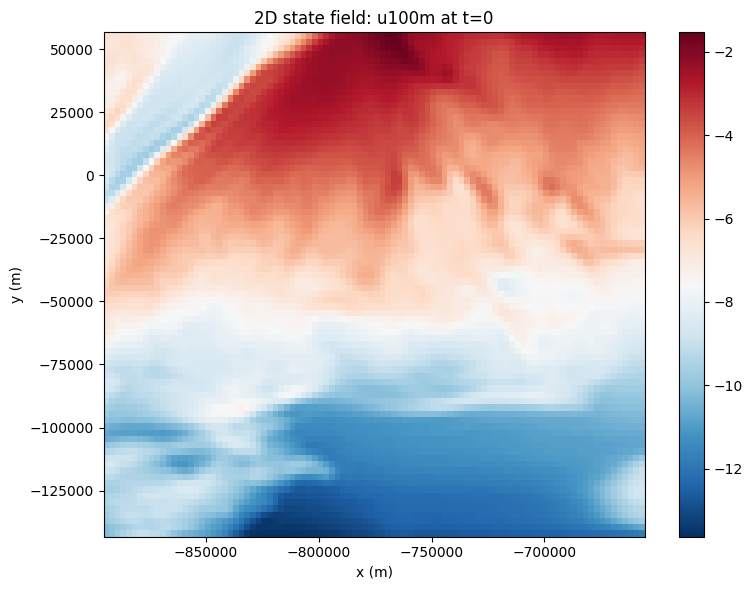

In [9]:
import numpy as np

ds = xr.open_zarr("tests/datastore_examples/mdp/danra_100m_winds/danra.datastore.zarr")
print(ds)

if "state" in ds:
    # First state feature (u100m) at the first timestep
    da = ds["state"].isel(time=0, state_feature=0)
    values = da.values

    x = ds.coords["x"].values if "x" in ds.coords else None
    y = ds.coords["y"].values if "y" in ds.coords else None

    fig, ax = plt.subplots(figsize=(8, 6))

    if x is not None and y is not None:
        x_unique = np.sort(np.unique(x))
        y_unique = np.sort(np.unique(y))
        xi = np.searchsorted(x_unique, x)
        yi = np.searchsorted(y_unique, y)
        grid = np.full((len(y_unique), len(x_unique)), np.nan)
        grid[yi, xi] = values
        pcm = ax.pcolormesh(x_unique, y_unique, grid, cmap="RdBu_r", shading="auto")
        x_units = ds.coords["x"].attrs.get("units", "")
        y_units = ds.coords["y"].attrs.get("units", "")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
    else:
        # Fallback: approximate square reshape if no grid coords
        n = len(values)
        ny = int(np.sqrt(n))
        nx = n // ny
        grid = values[: ny * nx].reshape(ny, nx)
        pcm = ax.pcolormesh(grid, cmap="RdBu_r", shading="auto")

    feature_names = list(ds["state_feature"].values) if "state_feature" in ds.coords else ["feature_0"]
    ax.set_title(f"2D state field: {feature_names[0]} at t=0")
    plt.colorbar(pcm, ax=ax)
    plt.tight_layout()
    plt.show()


## 3. Graph Generation

`neural-lam` uses a **graph** to define the message-passing structure of the GNN. Different graph types exist:

| Graph type  | Command flag                    | Use case               |
|-------------|----------------------------------|------------------------|
| L1-LAM      | `--name 1level --levels 1`       | Quick demo (this notebook) |
| GC-LAM      | `--name multiscale`              | Standard multi-scale model |
| Hi-LAM      | `--name hierarchical --hierarchical` | Hierarchical model (production) |

For this Hello World example we use the **L1 (single-level) graph** — the lightest option, ideal for CPU.

In [10]:
# Generate the single-level graph for fast CPU execution
# Graph files are stored in tests/datastore_examples/mdp/danra_100m_winds/graphs/1level/
!{sys.executable} -m neural_lam.create_graph \
    --config_path tests/datastore_examples/mdp/danra_100m_winds/config.yaml \
    --name 1level \
    --levels 1

2026-04-25 12:36:15.361 | INFO     | neural_lam.utils:log_on_rank_zero:457 - The loaded datastore contains the following features:
2026-04-25 12:36:15.361 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  state   : u100m v100m r2m t2m
2026-04-25 12:36:15.361 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  forcing : swavr0m
2026-04-25 12:36:15.361 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  static  : lsm orography
2026-04-25 12:36:15.361 | INFO     | neural_lam.utils:log_on_rank_zero:457 - With the following splits (over time):
2026-04-25 12:36:15.367 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  train   : 2022-04-01T00:00 to 2022-04-04T00:00
2026-04-25 12:36:15.370 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  val     : 2022-04-04T00:00 to 2022-04-07T00:00
2026-04-25 12:36:15.373 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  test    : 2022-04-07T00:00 to 2022-04-10T00:00
2026-04-25 12:36:15.381 | INFO     | __main__:create_graph:234 - Writing

In [11]:
# Confirm the graph was created
graph_files = glob.glob(
    "tests/datastore_examples/mdp/danra_100m_winds/graph/1level/**", recursive=True
)
print(f"Graph files created ({len(graph_files)}):", graph_files)

Graph files created (8): ['tests/datastore_examples/mdp/danra_100m_winds/graph/1level/', 'tests/datastore_examples/mdp/danra_100m_winds/graph/1level/m2g_features.pt', 'tests/datastore_examples/mdp/danra_100m_winds/graph/1level/m2g_edge_index.pt', 'tests/datastore_examples/mdp/danra_100m_winds/graph/1level/g2m_features.pt', 'tests/datastore_examples/mdp/danra_100m_winds/graph/1level/m2m_features.pt', 'tests/datastore_examples/mdp/danra_100m_winds/graph/1level/mesh_features.pt', 'tests/datastore_examples/mdp/danra_100m_winds/graph/1level/g2m_edge_index.pt', 'tests/datastore_examples/mdp/danra_100m_winds/graph/1level/m2m_edge_index.pt']


In [12]:
graph_dir = "tests/datastore_examples/mdp/danra_100m_winds/graph/1level"
graph_files = glob.glob(os.path.join(graph_dir, "**", "*.pt"), recursive=True)

if graph_files:
    print(f"✅ Graph created with {len(graph_files)} tensor file(s):")
    for f in sorted(graph_files):
        size_kb = os.path.getsize(f) / 1024
        print(f"  {os.path.basename(f):40s} {size_kb:.1f} KB")
else:
    print("❌ No graph .pt files found — check the create_graph output above.")

✅ Graph created with 7 tensor file(s):
  g2m_edge_index.pt                        200.3 KB
  g2m_features.pt                          150.6 KB
  m2g_edge_index.pt                        481.6 KB
  m2g_features.pt                          361.6 KB
  m2m_edge_index.pt                        87.7 KB
  m2m_features.pt                          66.1 KB
  mesh_features.pt                         7.3 KB


In [13]:
from IPython.display import HTML

config_path = "tests/datastore_examples/mdp/danra_100m_winds/config.yaml"
_, datastore = load_config_and_datastore(config_path=config_path)
xy = datastore.get_xy("state", stacked=True)
grid_pos = xy / np.max(np.abs(xy))

graph_dir = os.path.join(datastore.root_path, "graph", "1level")
hierarchical, graph_ldict = utils.load_graph(graph_dir_path=graph_dir)

fig = _plot_graph(grid_pos=grid_pos, hierarchical=hierarchical, graph_ldict=graph_ldict)
fig.write_html("graph_viz.html", include_plotlyjs="cdn")
print("Full interactive graph saved to graph_viz.html — open in a browser.")
fig.data = tuple(t for t in fig.data if t.name in {"M2M", "Mesh nodes"})
display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))

2026-04-25 12:36:17.560 | INFO     | neural_lam.utils:log_on_rank_zero:457 - The loaded datastore contains the following features:
2026-04-25 12:36:17.561 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  state   : u100m v100m r2m t2m
2026-04-25 12:36:17.561 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  forcing : swavr0m
2026-04-25 12:36:17.561 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  static  : lsm orography
2026-04-25 12:36:17.562 | INFO     | neural_lam.utils:log_on_rank_zero:457 - With the following splits (over time):
2026-04-25 12:36:17.568 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  train   : 2022-04-01T00:00 to 2022-04-04T00:00
2026-04-25 12:36:17.571 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  val     : 2022-04-04T00:00 to 2022-04-07T00:00
2026-04-25 12:36:17.575 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  test    : 2022-04-07T00:00 to 2022-04-10T00:00


Full interactive graph saved to graph_viz.html — open in a browser.


## 4. Training on CPU

We train the `graph_lam` model for **1 epoch** using the L1 graph. Key flags used here:

| Flag | Value | Why |
|------|-------|-----|
| `--model` | `graph_lam` | Simplest model — compatible with non-hierarchical graphs |
| `--graph` | `1level` | Must match the graph name used in the previous step |
| `--epochs` | `1` | Minimal run — just to verify the pipeline works end-to-end |
| `--processor_layers` | `2` | Reduced from default (4) for CPU |
| `--ar_steps_train` | `1` | Unroll 1 time-step during training — reduces memory and compute |
| `--ar_steps_eval` | `1` | Also 1 step for the val pass within this demo run |

**About logging:** By default, `neural-lam` logs via [Weights & Biases](https://wandb.ai). To suppress W&B upload during this demo, we set `WANDB_MODE=offline` so metrics are saved locally without requiring a W&B account or login.

In [14]:
os.environ["WANDB_MODE"] = "offline"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

!{sys.executable} -m neural_lam.train_model \
    --config_path tests/datastore_examples/mdp/danra_100m_winds/config.yaml \
    --model graph_lam \
    --graph 1level \
    --epochs 1 \
    --processor_layers 2 \
    --ar_steps_train 1 \
    --ar_steps_eval 1 \
    --num_workers 1 \
    --val_steps_to_log 1


Seed set to 42
2026-04-25 12:36:21.693 | INFO     | neural_lam.utils:log_on_rank_zero:457 - The loaded datastore contains the following features:
2026-04-25 12:36:21.693 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  state   : u100m v100m r2m t2m
2026-04-25 12:36:21.693 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  forcing : swavr0m
2026-04-25 12:36:21.693 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  static  : lsm orography
2026-04-25 12:36:21.693 | INFO     | neural_lam.utils:log_on_rank_zero:457 - With the following splits (over time):
2026-04-25 12:36:21.700 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  train   : 2022-04-01T00:00 to 2022-04-04T00:00
2026-04-25 12:36:21.703 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  val     : 2022-04-04T00:00 to 2022-04-07T00:00
2026-04-25 12:36:21.706 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  test    : 2022-04-07T00:00 to 2022-04-10T00:00
2026-04-25 12:36:21.768 | INFO     | neural_lam.utils:log

In [15]:
# Find the checkpoint saved during training
ckpts = glob.glob("saved_models/**/*.ckpt", recursive=True)
print("Checkpoints found:", ckpts)

Checkpoints found: ['saved_models/train-graph_lam-2x64-04_25_11-0791/min_val_loss.ckpt', 'saved_models/train-graph_lam-2x64-04_25_11-0791/last.ckpt', 'saved_models/train-graph_lam-2x64-04_03_18-7348/min_val_loss.ckpt', 'saved_models/train-graph_lam-2x64-04_03_18-7348/last.ckpt', 'saved_models/train-graph_lam-2x64-04_25_11-7489/min_val_loss.ckpt', 'saved_models/train-graph_lam-2x64-04_25_11-7489/last.ckpt', 'saved_models/train-graph_lam-2x64-04_25_12-5124/min_val_loss.ckpt', 'saved_models/train-graph_lam-2x64-04_25_12-5124/last.ckpt', 'saved_models/train-graph_lam-2x64-04_25_11-8610/min_val_loss.ckpt', 'saved_models/train-graph_lam-2x64-04_25_11-8610/last.ckpt']


## 5. Evaluation & Visualization

Evaluation reuses the same `train_model` command with `--eval test` and the `--load` flag pointing to the checkpoint from training.

Example predictions are plotted automatically and saved by the logger. Set `--n_example_pred` to control how many prediction plots to produce.

In [16]:
ckpts = glob.glob("saved_models/**/*.ckpt", recursive=True)

if not ckpts:
    print("❌ No checkpoint found — make sure the training cell above completed without errors.")
    ckpt_path = None
else:
    ckpt_path = max(ckpts, key=os.path.getmtime)
    print(f"✅ Using checkpoint: {ckpt_path}")

✅ Using checkpoint: saved_models/train-graph_lam-2x64-04_25_12-5124/last.ckpt


In [17]:
import argparse
import torch
from neural_lam.config import (
    DatastoreSelection, ManualStateFeatureWeighting, NeuralLAMConfig,
    OutputClamping, TrainingConfig, UniformFeatureWeighting,
)

torch.serialization.add_safe_globals([
    argparse.Namespace, DatastoreSelection, ManualStateFeatureWeighting,
    NeuralLAMConfig, OutputClamping, TrainingConfig, UniformFeatureWeighting,
])


In [18]:
os.environ["WANDB_MODE"] = "offline"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

!{sys.executable} -m neural_lam.train_model \
    --config_path tests/datastore_examples/mdp/danra_100m_winds/config.yaml \
    --model graph_lam \
    --graph 1level \
    --eval test \
    --load {ckpt_path} \
    --processor_layers 2 \
    --n_example_pred 2 \
    --ar_steps_eval 4 \
    --num_workers 1 \
    --val_steps_to_log 1


Seed set to 42
2026-04-25 12:36:46.405 | INFO     | neural_lam.utils:log_on_rank_zero:457 - The loaded datastore contains the following features:
2026-04-25 12:36:46.405 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  state   : u100m v100m r2m t2m
2026-04-25 12:36:46.406 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  forcing : swavr0m
2026-04-25 12:36:46.406 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  static  : lsm orography
2026-04-25 12:36:46.406 | INFO     | neural_lam.utils:log_on_rank_zero:457 - With the following splits (over time):
2026-04-25 12:36:46.413 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  train   : 2022-04-01T00:00 to 2022-04-04T00:00
2026-04-25 12:36:46.416 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  val     : 2022-04-04T00:00 to 2022-04-07T00:00
2026-04-25 12:36:46.418 | INFO     | neural_lam.utils:log_on_rank_zero:457 -  test    : 2022-04-07T00:00 to 2022-04-10T00:00
2026-04-25 12:36:46.482 | INFO     | neural_lam.utils:log

RMSE scorecard: wandb/latest-run/files/media/images/test_rmse_32_f471271df024429b645d.png


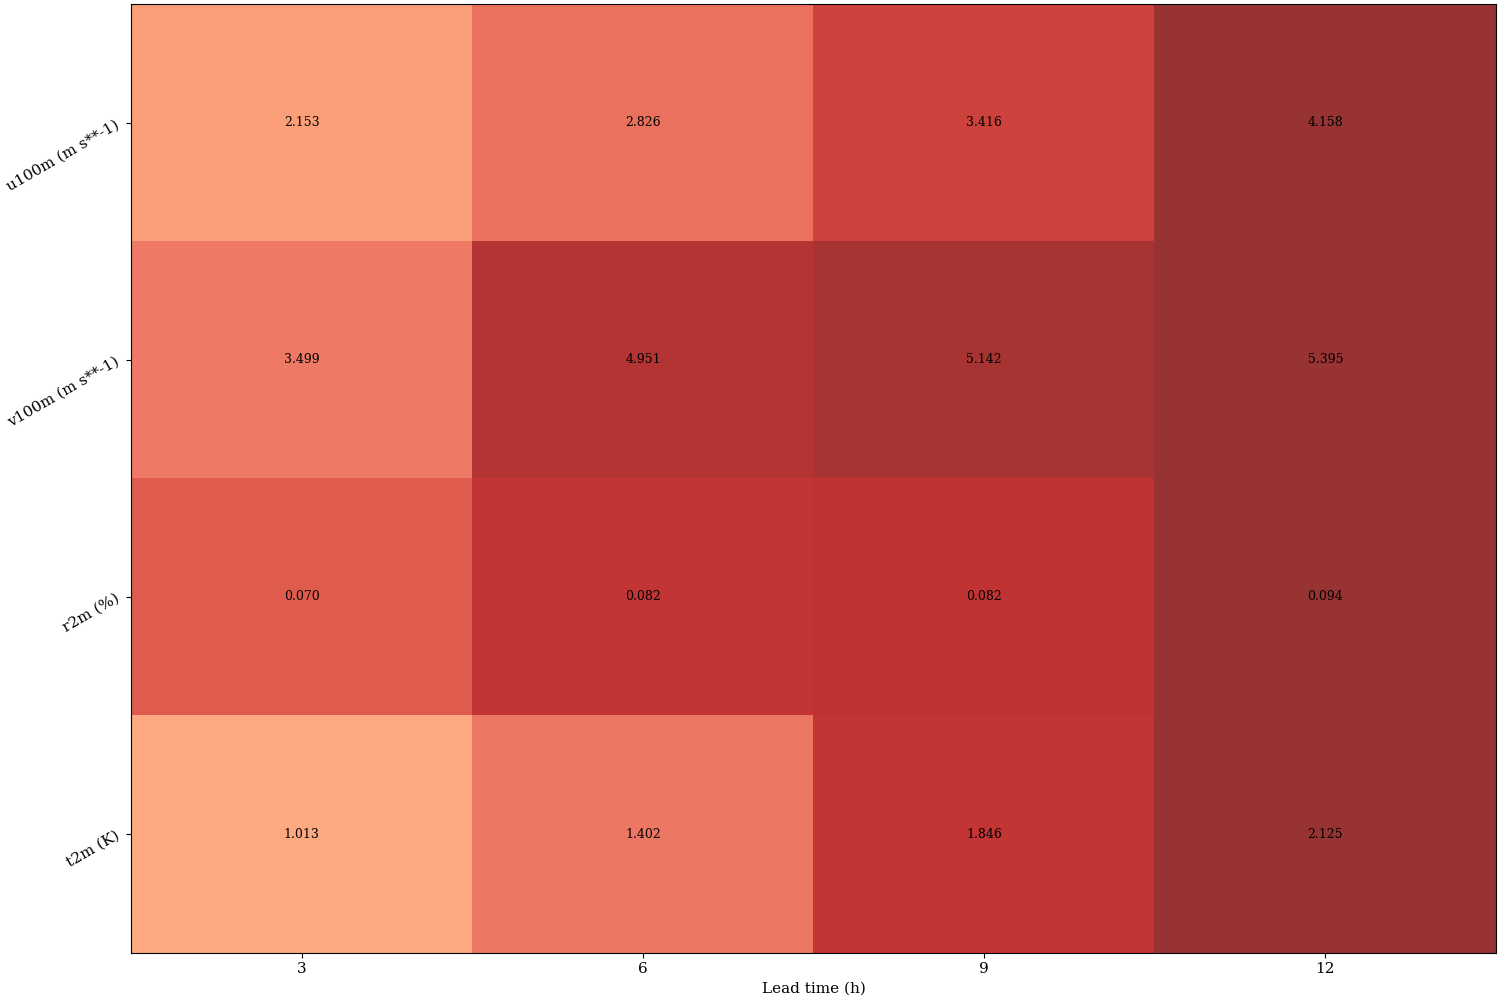

Showing 2 of 32 prediction plot(s):
  wandb/latest-run/files/media/images/r2m_example_1_10_9ad68b084d5b87e844ce.png


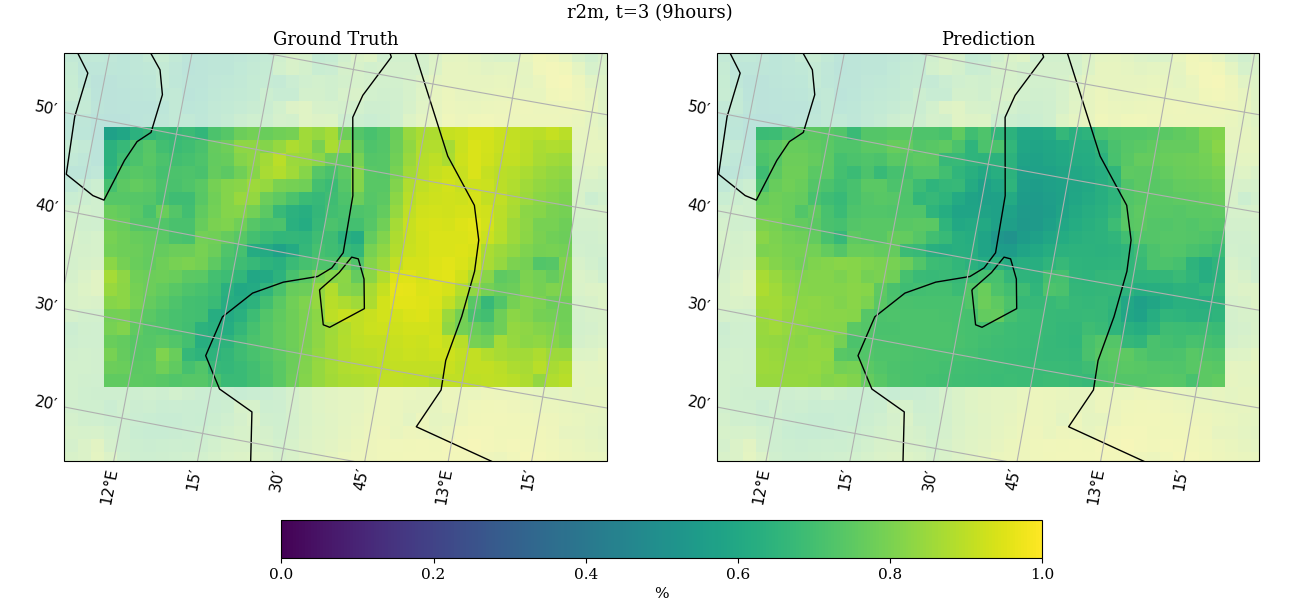

  wandb/latest-run/files/media/images/r2m_example_1_14_f17a0d17a86ced57621b.png


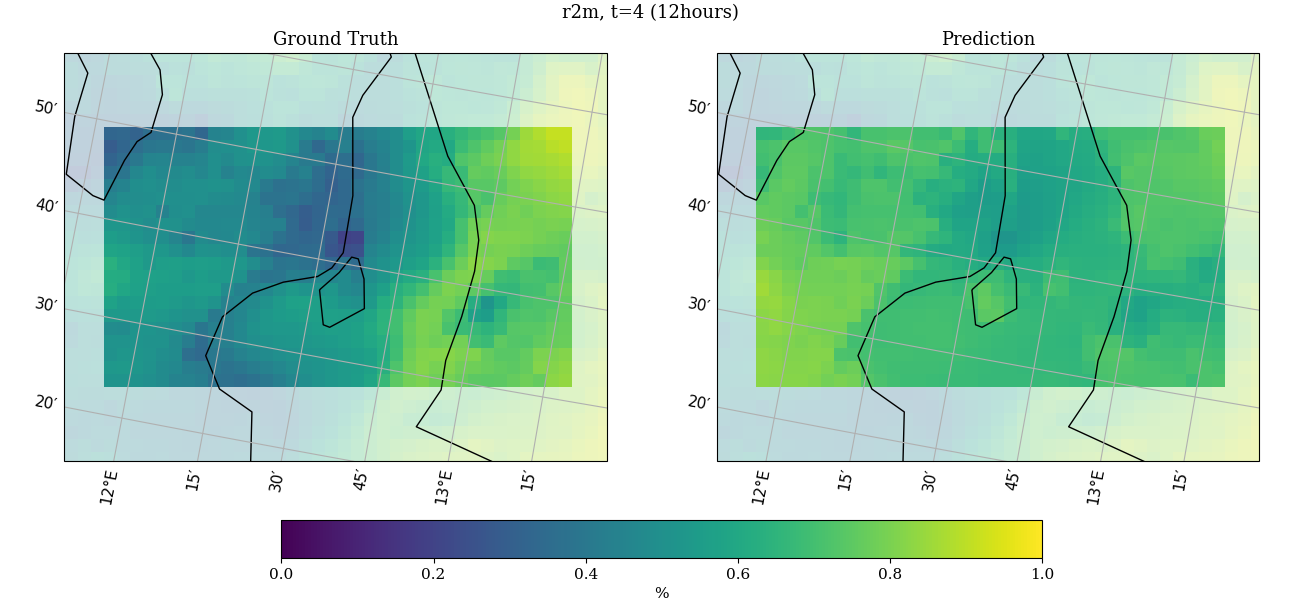

In [19]:
img_dir = "wandb/latest-run/files/media/images"
rmse_plots = sorted(glob.glob(os.path.join(img_dir, "test_rmse_*.png")))
if rmse_plots:
    print("RMSE scorecard:", rmse_plots[0])
    display(Image(filename=rmse_plots[0]))
else:
    print("test_rmse plot not found — check eval output above.")
example_plots = sorted(glob.glob(os.path.join(img_dir, "*_example_*.png")))
if example_plots:
    n_show = min(2, len(example_plots))
    print(f"Showing {n_show} of {len(example_plots)} prediction plot(s):")
    for p in example_plots[:n_show]:
        print(" ", p)
        display(Image(filename=p))
else:
    print("No prediction plots found — check eval output above.")

## 6. Scaling Tips & Next Steps

### 🔁 Use a larger / hierarchical graph

For a production-quality run, switch to the hierarchical Hi-LAM graph:

```bash
python -m neural_lam.create_graph \
    --config_path <your_config.yaml> \
    --name hierarchical \
    --hierarchical

python -m neural_lam.train_model \
    --config_path <your_config.yaml> \
    --model hi_lam \
    --graph hierarchical \
    --epochs 200
```

### ⚡ Enable GPU training

Simply replace the CPU-only `torch` install with the CUDA variant and `--devices` will auto-detect your GPU:
```bash
pip install torch --index-url https://download.pytorch.org/whl/cu121
```

### 📦 Use larger / full DANRA data

Modify `danra.datastore.yaml` to extend the `coord_ranges.time` window, or point `inputs[*].path` at a larger dataset. See the [mllam-data-prep README](https://github.com/mllam/mllam-data-prep) for full configuration options.

For large datasets (≥10 GB), use parallel preprocessing:
```bash
python -m mllam_data_prep \
    <your_datastore.yaml> \
    --dask-distributed-local-core-fraction 0.5
```

### 📊 Enable cloud logging with W&B

Remove the `WANDB_MODE=offline` line (or set it to `online`) and optionally set `--logger wandb --logger-project <your-project-name>`.

### 🔗 Further reading

- [neural-lam README](https://github.com/mllam/neural-lam)
- [mllam-data-prep](https://github.com/mllam/mllam-data-prep)
- [Graph-based Neural Weather Prediction (NeurIPS 2023)](https://arxiv.org/abs/2309.17370)
- [Probabilistic Weather Forecasting with Hierarchical GNNs (NeurIPS 2024)](https://arxiv.org/abs/2406.04759)